# Import tools

In [1]:
import nmtk
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
from pathlib import Path


# Set folder of a patient

In [2]:
folder = "/crnldata/REA_NEURO_MULTI_ICU/raw_data/MF12/"
folder = Path(folder)

# Load EEG

In [3]:
# raw_eeg, srate, chan_names = nmtk.load_with_pycns(folder = folder,  stream_name='EEG', index_selection_slice=slice(110_000_000, 110_100_000))
raw_eeg, srate, chan_names = nmtk.load_with_pycns(folder = folder,  stream_name='EEG', index_selection_slice=slice(50_000_000, 50_100_000))

# Select 2 channel and compute bipolar derivation

In [4]:
chan1 = 'C3'
chan2 = 'Cz'
one_signal = raw_eeg[:,chan_names.index(chan1)] - raw_eeg[:,chan_names.index(chan2)]
times = np.arange(one_signal.size) / srate

# Preproc signal

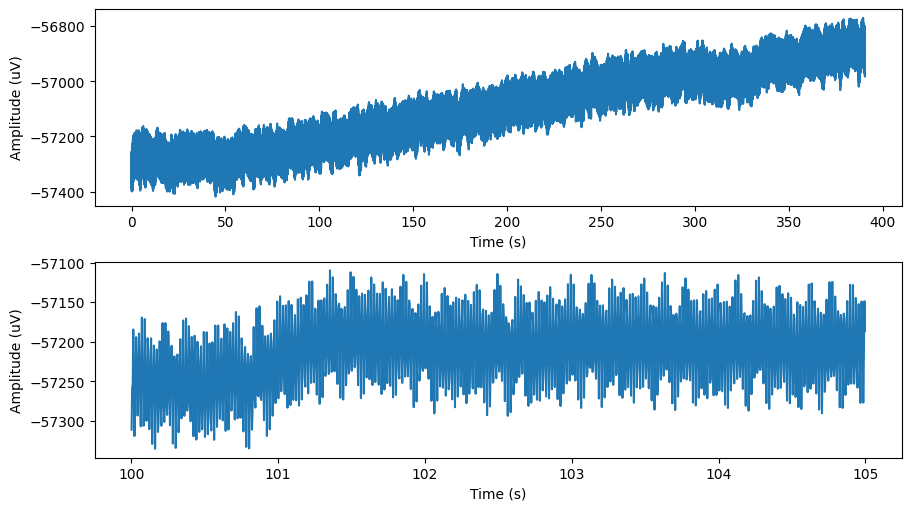

In [5]:
fig, axs = plt.subplots(nrows = 2, constrained_layout = True, figsize = (9,5))
ax = axs[0]
ax.set_ylabel('Amplitude (uV)')
ax.set_xlabel('Time (s)')
ax.plot(times, one_signal)

ax = axs[1]
ax.set_ylabel('Amplitude (uV)')
ax.set_xlabel('Time (s)')
mask = (times > 100) & (times < 105)
ax.plot(times[mask], one_signal[mask])

In [6]:
one_signal = nmtk.iirfilt(one_signal, srate , lowcut = 1 , highcut = 30) # apply a bandpass filter 1 to 30 Hz

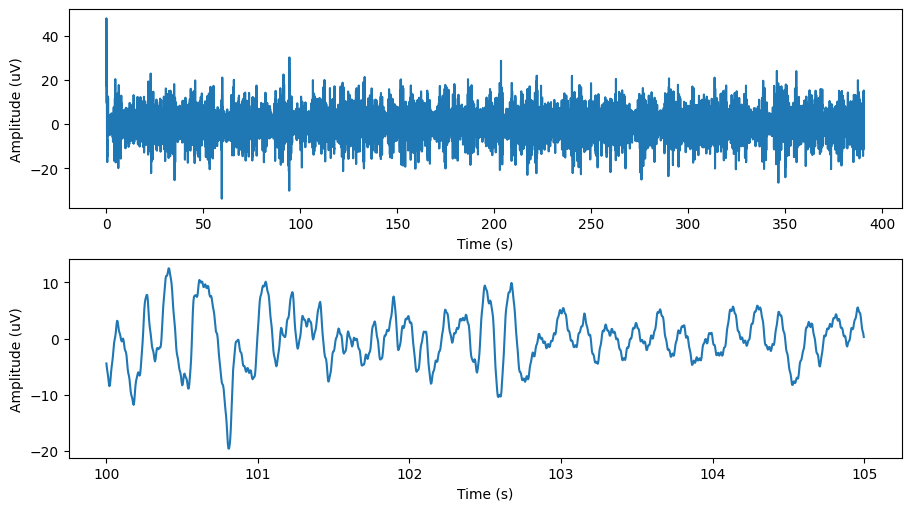

In [7]:
fig, axs = plt.subplots(nrows = 2, constrained_layout = True, figsize = (9,5))
ax = axs[0]
ax.set_ylabel('Amplitude (uV)')
ax.set_xlabel('Time (s)')
ax.plot(times, one_signal)

ax = axs[1]
ax.set_ylabel('Amplitude (uV)')
ax.set_xlabel('Time (s)')
mask = (times > 100) & (times < 105)
ax.plot(times[mask], one_signal[mask])

# Suppression ratio

In [8]:
one_signal = nmtk.iirfilt(one_signal, srate, lowcut = 1, highcut= 40)
ratios, ratio_times = nmtk.compute_suppression_ratio(one_signal, srate)

Text(0.5, 0, 'Time (s)')

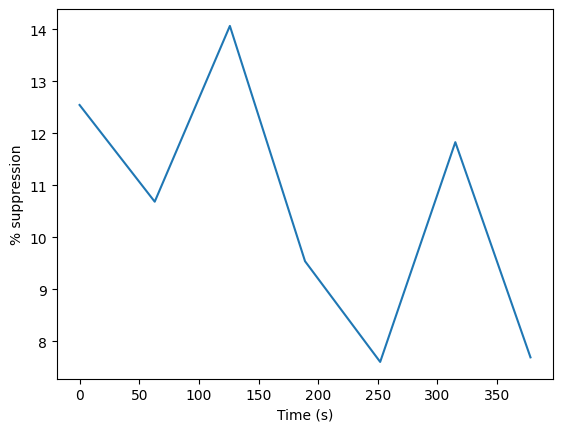

In [11]:
fig, ax = plt.subplots()
ax.plot(ratio_times, ratios)
ax.set_ylabel('% suppression')
ax.set_xlabel('Time (s)')

# Spectral features

In [17]:
win_size_s = 2
f, Pxx = scipy.signal.welch(one_signal, srate, nperseg = int(srate * win_size_s)) # compute spectral power using wlech method

Text(0.5, 0, 'Frequency (Hz)')

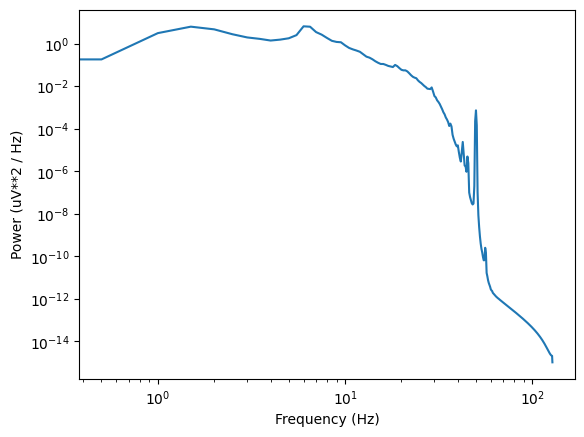

In [16]:
fig, ax = plt.subplots()
ax.loglog(f, Pxx)
ax.set_ylabel('Power (uV**2 / Hz)')
ax.set_xlabel('Frequency (Hz)')

## Alpha / Delta power and ratio

In [20]:
alpha_band = (8, 12)
delta_band = (1, 4)

alpha_power = np.trapz(Pxx[(f > alpha_band[0]) & (f < alpha_band[1]) ])
delta_power = np.trapz(Pxx[(f > delta_band[0]) & (f < delta_band[1]) ])

print('alpha power :', alpha_power)
print('delta power :', delta_power)
print('alpha / delta ratio:', alpha_power / delta_power)

alpha power : 6.893940808461616
delta power : 18.141134637719343
alpha / delta ratio: 0.3800170687299581


## Spectral entropy

In [23]:
spectral_entropy = nmtk.compute_spectral_entropy(Pxx[( f > 1) & (f < 40)])
print('spectral entropy :', spectral_entropy)

spectral entropy : 0.7028470705429113
